# Projeto MNIST — Pipeline Preditivo Multiclasse

## Descrição

Apresentação de pipeline completo de Ciência de Dados e Machine Learning
para classificação de dígitos manuscritos utilizando o dataset MNIST.

Serão utilizados 3 diferentes modelos preditivos para avaliar sua eficácia:

- K-Nearest Neighbors (KNN);
- Random Forest;
- Multi-Layer Perceptron (MLP).

Será análise exploratória, pré-processamento, treinamento, avaliação comparativa e testes de robustez fora da distribuição original dos dados.

## Estrutura do Projeto

### Fase 1 — Carregamento e Análise Exploratória
- Download do MNIST;
- Dimensionalidade;
- Distribuição das classes;
- Visualização das imagens;
- Análise dos pixels.

### Fase 2 — Pré-processamento
- Divisão estratificada;
- Treino;
- Validação;
- Teste;
- Normalização.

### Fase 3 — Modelos
- KNN;
- Random Forest;
- MLP;
- Ajuste de hiperparâmetros.

### Fase 4 — Avaliação
- Accuracy;
- Precision;
- Recall;
- F1-Score;
- Classification Report;
- Matrizes de confusão;
- Tempo de treinamento;
- Tempo de inferência.

### Fase 5 — Robustez
- Class Masking;
- Inferência OOD;
- Overconfidence;
- Imagens manuscritas próprias.

In [1]:
# ============================================================
# INSTALAÇÃO DAS BIBLIOTECAS
# ============================================================

!pip install -q scikit-learn seaborn matplotlib pandas numpy pillow


In [2]:
# ============================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================

import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageOps, ImageEnhance

from sklearn.datasets import fetch_openml

from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

# Reprodutibilidade
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [3]:
# ============================================================
# CONFIGURAÇÕES GERAIS DO PROJETO
# ============================================================

RANDOM_STATE = 42

CLASSES_OCULTADAS = [4, 7]

print("Random State:", RANDOM_STATE)
print("Classes que serão ocultadas no teste OOD:", CLASSES_OCULTADAS)

Random State: 42
Classes que serão ocultadas no teste OOD: [4, 7]


# FASE 1 — CARREGAMENTO E ANÁLISE EXPLORATÓRIA

O primeiro passo consiste em carregar o dataset MNIST utilizando
`fetch_openml`.

O MNIST contém 70.000 imagens de dígitos manuscritos, sendo cada imagem
representada por uma matriz de 28 × 28 pixels.

Como os modelos clássicos de Machine Learning trabalham com dados
organizados em vetores, cada imagem possui 784 características:

28 × 28 = 784.

In [4]:
# ================================
# CARREGAR DATASET MNIST
# ================================

print("Baixando o dataset MNIST...")
print("Esse processo pode levar alguns minutos na primeira execução.\n")

mnist = fetch_openml(
    'mnist_784',
    version=1,
    as_frame=False,
    parser='auto'
)

print("Download finalizado com sucesso!")

Baixando o dataset MNIST...
Esse processo pode levar alguns minutos na primeira execução.

Download finalizado com sucesso!


In [5]:
# ============================================================
# SEPARAÇÃO ENTRE FEATURES (X) E RÓTULOS (y)
# ============================================================

X = mnist.data.astype(np.float32)
y = mnist.target.astype(np.int64)

print("Dimensionalidade de X:", X.shape)
print("Dimensionalidade de y:", y.shape)

print("\nPrimeiros 10 rótulos:")
print(y[:10])

Dimensionalidade de X: (70000, 784)
Dimensionalidade de y: (70000,)

Primeiros 10 rótulos:
[5 0 4 1 9 2 1 3 1 4]


In [6]:
# ============================================================
# DISTRIBUIÇÃO DAS CLASSES
# ============================================================

contagem_classes = pd.Series(y).value_counts().sort_index()

df_classes = pd.DataFrame({
    "Dígito": contagem_classes.index,
    "Quantidade": contagem_classes.values
})

display(df_classes)

,Dígito,Quantidade
0,0,6903
1,1,7877
2,2,6990
3,3,7141
4,4,6824
5,5,6313
6,6,6876
7,7,7293
8,8,6825
9,9,6958


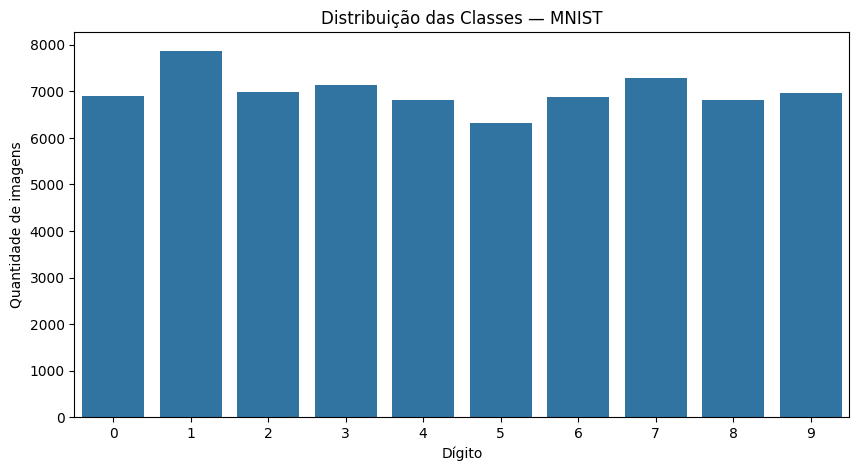

In [7]:
# ============================================================
# VISUALIZAÇÃO DO BALANCEAMENTO
# ============================================================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df_classes,
    x="Dígito",
    y="Quantidade"
)

plt.title("Distribuição das Classes — MNIST")
plt.xlabel("Dígito")
plt.ylabel("Quantidade de imagens")

plt.show()

## Interpretação da Distribuição das Classes

A distribuição das classes no MNIST é aproximadamente equilibrada.

Isso significa que os dez dígitos possuem quantidades semelhantes de
exemplos e não existe uma classe majoritária suficientemente dominante
para caracterizar um forte desequilíbrio.

Essa característica é importante porque permite comparar os modelos
utilizando métricas tradicionais como Accuracy, Precision, Recall e
F1-Score.

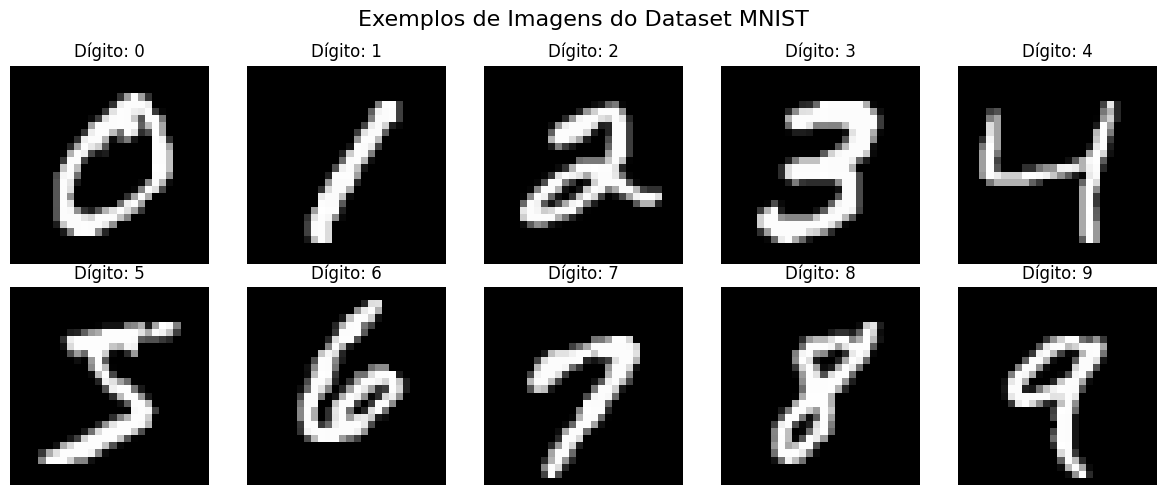

In [8]:
# ============================================================
# VISUALIZAÇÃO DE UM EXEMPLO DE CADA DÍGITO
# ============================================================

plt.figure(figsize=(12, 5))

for digito in range(10):

    indice = np.where(y == digito)[0][0]

    imagem = X[indice].reshape(28, 28)

    plt.subplot(2, 5, digito + 1)

    plt.imshow(imagem, cmap="gray")

    plt.title(f"Dígito: {digito}")

    plt.axis("off")

plt.suptitle(
    "Exemplos de Imagens do Dataset MNIST",
    fontsize=16
)

plt.tight_layout()

plt.show()

In [9]:
# ============================================================
# ANÁLISE DA ESCALA DOS PIXELS
# ============================================================

print("Valor mínimo dos pixels:", X.min())
print("Valor máximo dos pixels:", X.max())

print(
    "Quantidade de características por imagem:",
    X.shape[1]
)

print(
    "Verificação:",
    28 * 28,
    "pixels"
)

Valor mínimo dos pixels: 0.0
Valor máximo dos pixels: 255.0
Quantidade de características por imagem: 784
Verificação: 784 pixels


## Estrutura dos Dados

As imagens do MNIST possuem resolução de 28 × 28 pixels.

Cada pixel possui uma intensidade normalmente representada no intervalo:

- 0 → preto;
- 255 → branco;
- valores intermediários → tons de cinza.

A imagem originalmente possui duas dimensões:

28 × 28.

Para utilizar modelos tradicionais de Machine Learning, a matriz é
transformada em um vetor:

28 × 28 = 784 características.

Dessa forma:

- cada linha de X representa uma imagem;
- cada uma das 784 colunas representa um pixel;
- y representa o dígito correspondente.

Portanto, o problema pode ser representado como:

784 características → classificação entre 10 classes (0 a 9).

# FASE 2 — PRÉ-PROCESSAMENTO E DIVISÃO DOS DADOS

A base será dividida em:

- 70% para treinamento;
- 10% para validação;
- 20% para teste.

A divisão será estratificada utilizando `stratify=y`, garantindo que
a proporção das dez classes seja aproximadamente preservada nos três
conjuntos.

O conjunto de teste permanecerá separado até a avaliação final.

In [10]:
# ============================================================
# DIVISÃO DOS DADOS
# ============================================================

# Primeiro:
# 80% desenvolvimento
# 20% teste

X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

# Depois:
# 70% total → treinamento
# 10% total → validação
#
# 10 / 80 = 0.125

X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.125,
    stratify=y_dev,
    random_state=RANDOM_STATE
)

print("Treinamento:", X_train.shape)
print("Validação:", X_val.shape)
print("Teste:", X_test.shape)

Treinamento: (49000, 784)
Validação: (7000, 784)
Teste: (14000, 784)


In [11]:
# ============================================================
# CONFERÊNCIA DAS PROPORÇÕES
# ============================================================

total = len(X)

print(
    f"Treinamento: {len(X_train):,} "
    f"({len(X_train)/total:.1%})"
)

print(
    f"Validação: {len(X_val):,} "
    f"({len(X_val)/total:.1%})"
)

print(
    f"Teste: {len(X_test):,} "
    f"({len(X_test)/total:.1%})"
)

Treinamento: 49,000 (70.0%)
Validação: 7,000 (10.0%)
Teste: 14,000 (20.0%)


In [12]:
# ============================================================
# NORMALIZAÇÃO DOS PIXELS
# ============================================================

X_train_scaled = X_train / 255.0
X_val_scaled = X_val / 255.0
X_test_scaled = X_test / 255.0

print(
    "Mínimo:",
    X_train_scaled.min()
)

print(
    "Máximo:",
    X_train_scaled.max()
)

print(
    "Tipo:",
    X_train_scaled.dtype
)

Mínimo: 0.0
Máximo: 1.0
Tipo: float32


## Justificativa da Normalização

Os pixels originalmente possuem valores entre 0 e 255.

Neste projeto, esses valores são transformados para o intervalo [0, 1]
dividindo cada pixel por 255.

A normalização é especialmente importante para:

### KNN

O KNN utiliza medidas de distância entre as imagens. Trabalhar com uma
escala padronizada facilita o cálculo dessas distâncias.

### MLP

A rede neural utiliza otimização baseada em gradientes. Valores de entrada
em uma escala menor tendem a proporcionar um processo de treinamento mais
estável.

### Random Forest

Árvores de decisão são menos sensíveis à escala das variáveis, mas manter
um pré-processamento consistente facilita a comparação entre os modelos.

# FASE 3 — IMPLEMENTAÇÃO DOS MODELOS

Serão utilizados três algoritmos com características diferentes:

### 1. KNN
Modelo baseado em distância.

### 2. Random Forest
Modelo baseado em múltiplas árvores de decisão.

### 3. MLP
Rede neural artificial multicamada.

Para cada modelo serão testadas algumas configurações de hiperparâmetros
utilizando exclusivamente o conjunto de treinamento e validação.

O conjunto de teste não será utilizado nessa etapa.

In [13]:
# ============================================================
# FUNÇÃO AUXILIAR PARA AVALIAÇÃO NA VALIDAÇÃO
# ============================================================

def avaliar_validacao(nome, modelo, X_val, y_val, tempo_treino):

    inicio = time.time()

    y_pred = modelo.predict(X_val)

    tempo_inferencia = time.time() - inicio

    return {
        "Modelo": nome,
        "Accuracy": accuracy_score(y_val, y_pred),
        "F1-Score Weighted": f1_score(
            y_val,
            y_pred,
            average="weighted"
        ),
        "Tempo Treino (s)": tempo_treino,
        "Tempo Inferência (s)": tempo_inferencia
    }

In [14]:
# ============================================================
# AJUSTE DE HIPERPARÂMETROS — KNN
# ============================================================

resultados_knn = []

valores_k = [3, 5, 7]
valores_weights = ["uniform", "distance"]

for k in valores_k:

    for weights in valores_weights:

        print(
            f"Treinando KNN com "
            f"k={k} | weights={weights}..."
        )

        modelo = KNeighborsClassifier(
            n_neighbors=k,
            weights=weights,
            n_jobs=-1
        )

        inicio = time.time()

        modelo.fit(
            X_train_scaled,
            y_train
        )

        tempo_treino = (
            time.time() - inicio
        )

        resultado = avaliar_validacao(
            f"KNN k={k} weights={weights}",
            modelo,
            X_val_scaled,
            y_val,
            tempo_treino
        )

        # Guardar os dois hiperparâmetros
        resultado["n_neighbors"] = k
        resultado["weights"] = weights

        resultados_knn.append(
            resultado
        )


# Criar tabela de resultados
df_knn_tuning = pd.DataFrame(
    resultados_knn
)

print("\n" + "=" * 70)
print("RESULTADOS DO AJUSTE DO KNN")
print("=" * 70)

display(df_knn_tuning)

Treinando KNN com k=3 | weights=uniform...
Treinando KNN com k=3 | weights=distance...
Treinando KNN com k=5 | weights=uniform...
Treinando KNN com k=5 | weights=distance...
Treinando KNN com k=7 | weights=uniform...
Treinando KNN com k=7 | weights=distance...

RESULTADOS DO AJUSTE DO KNN


,Modelo,Accuracy,F1-Score Weighted,Tempo Treino (s),Tempo Inferência (s),n_neighbors,weights
0,KNN k=3 weights=uniform,0.971857,0.971815,0.026720,21.295652,3,uniform
1,KNN k=3 weights=distance,0.972286,0.972253,0.018316,19.632815,3,distance
2,KNN k=5 weights=uniform,0.969429,0.969374,0.017488,20.639959,5,uniform
3,KNN k=5 weights=distance,0.971429,0.971400,0.018009,19.371409,5,distance
4,KNN k=7 weights=uniform,0.968429,0.968389,0.017375,21.516948,7,uniform
5,KNN k=7 weights=distance,0.969857,0.969836,0.017686,21.662718,7,distance


In [15]:
# ============================================================
# MELHOR CONFIGURAÇÃO KNN
# ============================================================

melhor_knn = df_knn_tuning.loc[
    df_knn_tuning[
        "F1-Score Weighted"
    ].idxmax()
]

melhor_k = int(
    melhor_knn["n_neighbors"]
)

melhor_weights = (
    melhor_knn["weights"]
)

print("=" * 70)
print("MELHOR CONFIGURAÇÃO DO KNN")
print("=" * 70)

print(
    "Melhor n_neighbors:",
    melhor_k
)

print(
    "Melhor weights:",
    melhor_weights
)

print(
    "F1-Score Weighted:",
    f"{melhor_knn['F1-Score Weighted']:.4f}"
)

MELHOR CONFIGURAÇÃO DO KNN
Melhor n_neighbors: 3
Melhor weights: distance
F1-Score Weighted: 0.9723


In [16]:
# ============================================================
# AJUSTE DE HIPERPARÂMETROS — RANDOM FOREST
# ============================================================

configuracoes_rf = [
    {
        "n_estimators": 100,
        "max_depth": 15
    },
    {
        "n_estimators": 100,
        "max_depth": 20
    },
    {
        "n_estimators": 150,
        "max_depth": 20
    }
]

resultados_rf = []

for config in configuracoes_rf:

    print(
        "Treinando RF:",
        config
    )

    modelo = RandomForestClassifier(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    inicio = time.time()

    modelo.fit(
        X_train_scaled,
        y_train
    )

    tempo_treino = time.time() - inicio

    resultado = avaliar_validacao(
        "Random Forest",
        modelo,
        X_val_scaled,
        y_val,
        tempo_treino
    )

    resultado.update(config)

    resultados_rf.append(resultado)

df_rf_tuning = pd.DataFrame(resultados_rf)

display(df_rf_tuning)

Treinando RF: {'n_estimators': 100, 'max_depth': 15}
Treinando RF: {'n_estimators': 100, 'max_depth': 20}
Treinando RF: {'n_estimators': 150, 'max_depth': 20}


,Modelo,Accuracy,F1-Score Weighted,Tempo Treino (s),Tempo Inferência (s),n_estimators,max_depth
0,Random Forest,0.963000,0.962963,31.572206,0.224714,100,15
1,Random Forest,0.965143,0.965090,33.891359,0.335931,100,20
2,Random Forest,0.965857,0.965813,52.522656,0.370514,150,20


In [17]:
# ============================================================
# MELHOR CONFIGURAÇÃO RANDOM FOREST
# ============================================================

melhor_rf = df_rf_tuning.loc[
    df_rf_tuning["F1-Score Weighted"].idxmax()
]

melhor_n_estimators = int(
    melhor_rf["n_estimators"]
)

melhor_max_depth = int(
    melhor_rf["max_depth"]
)

print(
    "Melhor n_estimators:",
    melhor_n_estimators
)

print(
    "Melhor max_depth:",
    melhor_max_depth
)

Melhor n_estimators: 150
Melhor max_depth: 20


In [18]:
# ============================================================
# AJUSTE DE HIPERPARÂMETROS — MLP
# ============================================================

configuracoes_mlp = [
    {
        "hidden_layer_sizes": (128,),
        "learning_rate_init": 0.001
    },
    {
        "hidden_layer_sizes": (128, 64),
        "learning_rate_init": 0.001
    },
    {
        "hidden_layer_sizes": (128, 64),
        "learning_rate_init": 0.0005
    }
]

resultados_mlp = []


for configuracao in configuracoes_mlp:

    arquitetura = configuracao["hidden_layer_sizes"]
    learning_rate = configuracao["learning_rate_init"]

    print("=" * 60)
    print("Treinando MLP")
    print("Arquitetura:", arquitetura)
    print("Learning rate:", learning_rate)
    print("=" * 60)

    modelo = MLPClassifier(
        hidden_layer_sizes=arquitetura,
        activation="relu",
        solver="adam",
        learning_rate_init=learning_rate,
        max_iter=30,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=RANDOM_STATE
    )

    inicio = time.time()

    modelo.fit(
        X_train_scaled,
        y_train
    )

    tempo = time.time() - inicio

    y_pred = modelo.predict(
        X_val_scaled
    )

    accuracy = accuracy_score(
        y_val,
        y_pred
    )

    f1 = f1_score(
        y_val,
        y_pred,
        average="weighted"
    )

    resultados_mlp.append({
        "Arquitetura": arquitetura,
        "Learning Rate": learning_rate,
        "Accuracy": accuracy,
        "F1": f1,
        "Tempo": tempo
    })


# ============================================================
# TABELA DE RESULTADOS
# ============================================================

df_mlp_tuning = pd.DataFrame(
    resultados_mlp
)

print("\n")
print("=" * 60)
print("RESULTADOS DO TUNING DO MLP")
print("=" * 60)

display(df_mlp_tuning)

Treinando MLP
Arquitetura: (128,)
Learning rate: 0.001
Treinando MLP
Arquitetura: (128, 64)
Learning rate: 0.001
Treinando MLP
Arquitetura: (128, 64)
Learning rate: 0.0005


RESULTADOS DO TUNING DO MLP


,Arquitetura,Learning Rate,Accuracy,F1,Tempo
0,"(128,)",0.0010,0.973143,0.973134,41.502834
1,"(128, 64)",0.0010,0.976857,0.976851,50.046573
2,"(128, 64)",0.0005,0.975857,0.975859,44.003455


In [19]:
# ============================================================
# MELHOR CONFIGURAÇÃO MLP
# ============================================================

melhor_mlp = df_mlp_tuning.loc[
    df_mlp_tuning["F1"].idxmax()
]


# Recuperar os hiperparâmetros vencedores

melhor_hidden = tuple(
    melhor_mlp["Arquitetura"]
)

melhor_learning_rate = float(
    melhor_mlp["Learning Rate"]
)


# ============================================================
# EXIBIR RESULTADO
# ============================================================

print("=" * 60)
print("MELHOR CONFIGURAÇÃO DO MLP")
print("=" * 60)

print(
    "Arquitetura:",
    melhor_hidden
)

print(
    "Learning rate:",
    melhor_learning_rate
)

print(
    "Accuracy na validação:",
    f"{melhor_mlp['Accuracy']:.4f}"
)

print(
    "F1-Score na validação:",
    f"{melhor_mlp['F1']:.4f}"
)

print(
    "Tempo de treinamento:",
    f"{melhor_mlp['Tempo']:.2f} segundos"
)

MELHOR CONFIGURAÇÃO DO MLP
Arquitetura: (128, 64)
Learning rate: 0.001
Accuracy na validação: 0.9769
F1-Score na validação: 0.9769
Tempo de treinamento: 50.05 segundos


In [20]:
# ============================================================
# TREINAMENTO DEFINITIVO DOS MODELOS
# ============================================================

print("=" * 60)
print("PREPARAÇÃO DO TREINAMENTO DEFINITIVO")
print("=" * 60)


# ============================================================
# COMBINAR TREINO + VALIDAÇÃO
# ============================================================

X_train_final = np.concatenate(
    [X_train_scaled, X_val_scaled],
    axis=0
)

y_train_final = np.concatenate(
    [y_train, y_val],
    axis=0
)

print(
    "Amostras utilizadas no treinamento final:",
    len(X_train_final)
)

print(
    "Amostras reservadas para teste:",
    len(X_test_scaled)
)


# ============================================================
# DICIONÁRIOS
# ============================================================

modelos = {}

tempos_treino = {}


# ============================================================
# 1. KNN
# ============================================================

print("\n")
print("=" * 60)
print("1. TREINANDO KNN")
print("=" * 60)

knn_final = KNeighborsClassifier(
    n_neighbors=melhor_k,
    weights=melhor_weights,
    n_jobs=-1
)

inicio = time.time()

knn_final.fit(
    X_train_final,
    y_train_final
)

tempo_knn = time.time() - inicio

modelos["KNN"] = knn_final
tempos_treino["KNN"] = tempo_knn

print(
    f"KNN concluído em {tempo_knn:.2f} segundos."
)


# ============================================================
# 2. RANDOM FOREST
# ============================================================

print("\n")
print("=" * 60)
print("2. TREINANDO RANDOM FOREST")
print("=" * 60)

rf_final = RandomForestClassifier(
    n_estimators=melhor_n_estimators,
    max_depth=melhor_max_depth,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

inicio = time.time()

rf_final.fit(
    X_train_final,
    y_train_final
)

tempo_rf = time.time() - inicio

modelos["Random Forest"] = rf_final
tempos_treino["Random Forest"] = tempo_rf

print(
    f"Random Forest concluído em {tempo_rf:.2f} segundos."
)


# ============================================================
# 3. MLP
# ============================================================

print("\n")
print("=" * 60)
print("3. TREINANDO MLP")
print("=" * 60)

print(
    "Arquitetura:",
    melhor_hidden
)

print(
    "Learning rate:",
    melhor_learning_rate
)

mlp_final = MLPClassifier(
    hidden_layer_sizes=melhor_hidden,
    activation="relu",
    solver="adam",
    learning_rate_init=melhor_learning_rate,
    max_iter=30,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=RANDOM_STATE
)

inicio = time.time()

mlp_final.fit(
    X_train_final,
    y_train_final
)

tempo_mlp = time.time() - inicio

modelos["MLP"] = mlp_final
tempos_treino["MLP"] = tempo_mlp

print(
    f"MLP concluído em {tempo_mlp:.2f} segundos."
)


# ============================================================
# RESUMO DOS TEMPOS
# ============================================================

print("\n")
print("=" * 60)
print("TREINAMENTO DEFINITIVO CONCLUÍDO")
print("=" * 60)

for nome, tempo in tempos_treino.items():

    print(
        f"{nome}: {tempo:.2f} segundos"
    )

PREPARAÇÃO DO TREINAMENTO DEFINITIVO
Amostras utilizadas no treinamento final: 56000
Amostras reservadas para teste: 14000


1. TREINANDO KNN
KNN concluído em 0.02 segundos.


2. TREINANDO RANDOM FOREST
Random Forest concluído em 60.96 segundos.


3. TREINANDO MLP
Arquitetura: (128, 64)
Learning rate: 0.001
MLP concluído em 62.41 segundos.


TREINAMENTO DEFINITIVO CONCLUÍDO
KNN: 0.02 segundos
Random Forest: 60.96 segundos
MLP: 62.41 segundos


In [21]:
# ============================================================
# AVALIAÇÃO DOS MODELOS NO CONJUNTO DE TESTE
# ============================================================

resultados_teste = []

predicoes = {}

tempos_predicao = {}


for nome, modelo in modelos.items():

    print("=" * 60)
    print(f"AVALIANDO: {nome}")
    print("=" * 60)

    # --------------------------------------------------------
    # Tempo de inferência
    # --------------------------------------------------------

    inicio = time.time()

    y_pred = modelo.predict(
        X_test_scaled
    )

    tempo_predicao = time.time() - inicio

    predicoes[nome] = y_pred

    tempos_predicao[nome] = tempo_predicao


    # --------------------------------------------------------
    # Métricas
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )


    resultados_teste.append({
        "Modelo": nome,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Tempo Inferência (s)": tempo_predicao
    })


# ============================================================
# TABELA FINAL
# ============================================================

df_resultados = pd.DataFrame(
    resultados_teste
)

df_resultados = df_resultados.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)


print("\n")
print("=" * 60)
print("RESULTADOS NO CONJUNTO DE TESTE")
print("=" * 60)

display(
    df_resultados
)

AVALIANDO: KNN
AVALIANDO: Random Forest
AVALIANDO: MLP


RESULTADOS NO CONJUNTO DE TESTE


,Modelo,Accuracy,Precision,Recall,F1-Score,Tempo Inferência (s)
0,MLP,0.978500,0.978548,0.978500,0.978498,0.108635
1,KNN,0.973214,0.973408,0.973214,0.973185,45.191707
2,Random Forest,0.968000,0.967992,0.968000,0.967979,0.723547


In [22]:
# ============================================================
# SELEÇÃO AUTOMÁTICA DO MELHOR MODELO
# ============================================================

melhor_modelo_nome = df_resultados.loc[
    0,
    "Modelo"
]

melhor_f1 = df_resultados.loc[
    0,
    "F1-Score"
]

melhor_accuracy = df_resultados.loc[
    0,
    "Accuracy"
]


print("=" * 60)
print("MELHOR MODELO")
print("=" * 60)

print(
    "Modelo:",
    melhor_modelo_nome
)

print(
    "Accuracy:",
    f"{melhor_accuracy:.4f}"
)

print(
    "F1-Score:",
    f"{melhor_f1:.4f}"
)

MELHOR MODELO
Modelo: MLP
Accuracy: 0.9785
F1-Score: 0.9785


In [23]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("=" * 60)
print(
    f"CLASSIFICATION REPORT — {melhor_modelo_nome}"
)
print("=" * 60)

print(
    classification_report(
        y_test,
        predicoes[melhor_modelo_nome],
        digits=4
    )
)

CLASSIFICATION REPORT — MLP
              precision    recall  f1-score   support

           0     0.9752    0.9957    0.9853      1381
           1     0.9879    0.9860    0.9870      1575
           2     0.9758    0.9807    0.9782      1398
           3     0.9761    0.9713    0.9737      1428
           4     0.9852    0.9722    0.9786      1365
           5     0.9824    0.9699    0.9761      1263
           6     0.9854    0.9840    0.9847      1375
           7     0.9774    0.9788    0.9781      1459
           8     0.9786    0.9700    0.9742      1365
           9     0.9610    0.9748    0.9679      1391

    accuracy                         0.9785     14000
   macro avg     0.9785    0.9783    0.9784     14000
weighted avg     0.9785    0.9785    0.9785     14000



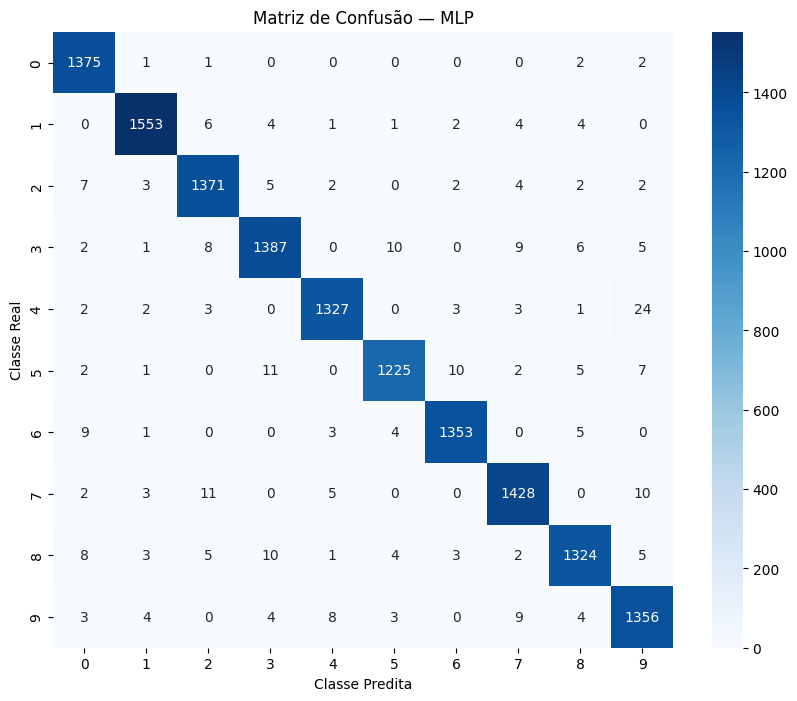

In [24]:
# ============================================================
# MATRIZ DE CONFUSÃO
# ============================================================

modelo_melhor = modelos[
    melhor_modelo_nome
]

y_pred_melhor = predicoes[
    melhor_modelo_nome
]

cm = confusion_matrix(
    y_test,
    y_pred_melhor,
    labels=np.arange(10)
)


plt.figure(
    figsize=(10, 8)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=np.arange(10),
    yticklabels=np.arange(10)
)

plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")

plt.title(
    f"Matriz de Confusão — {melhor_modelo_nome}"
)

plt.show()

In [25]:
# ============================================================
# MAIOR CONFUSÃO
# ============================================================

cm_sem_diagonal = cm.copy()

np.fill_diagonal(
    cm_sem_diagonal,
    0
)

indice_maior_confusao = np.unravel_index(
    np.argmax(cm_sem_diagonal),
    cm_sem_diagonal.shape
)

classe_real = indice_maior_confusao[0]
classe_predita = indice_maior_confusao[1]

quantidade_confusoes = cm_sem_diagonal[
    classe_real,
    classe_predita
]


print("=" * 60)
print("MAIOR CONFUSÃO DO MODELO")
print("=" * 60)

print(
    f"Classe real: {classe_real}"
)

print(
    f"Classe predita: {classe_predita}"
)

print(
    f"Quantidade de erros: {quantidade_confusoes}"
)

MAIOR CONFUSÃO DO MODELO
Classe real: 4
Classe predita: 9
Quantidade de erros: 24


In [26]:
# ============================================================
# PREPARAÇÃO DO TESTE OOD
# ============================================================

print("=" * 70)
print("EXPERIMENTO OOD — CLASSES 4 E 7 OCULTADAS")
print("=" * 70)

# Classes que NÃO participarão do treinamento
CLASSES_OCULTADAS = [4, 7]

# Classes conhecidas pelo modelo
CLASSES_CONHECIDAS = [
    classe for classe in range(10)
    if classe not in CLASSES_OCULTADAS
]

print("Classes conhecidas:", CLASSES_CONHECIDAS)
print("Classes ocultadas:", CLASSES_OCULTADAS)

EXPERIMENTO OOD — CLASSES 4 E 7 OCULTADAS
Classes conhecidas: [0, 1, 2, 3, 5, 6, 8, 9]
Classes ocultadas: [4, 7]


In [27]:
# ============================================================
# CÉLULA 35 — SEPARAÇÃO DOS DADOS OOD
# ============================================================

# ------------------------------------------------------------
# TREINAMENTO
# ------------------------------------------------------------
# Utilizamos o conjunto final de treinamento, mas removemos
# completamente as classes 4 e 7.

mascara_treinamento_ood = np.isin(
    y_train_final,
    CLASSES_CONHECIDAS
)

X_train_ood = X_train_final[
    mascara_treinamento_ood
]

y_train_ood = y_train_final[
    mascara_treinamento_ood
]


# ------------------------------------------------------------
# TESTE OOD
# ------------------------------------------------------------
# O conjunto OOD contém EXCLUSIVAMENTE as classes 4 e 7.

mascara_teste_ood = np.isin(
    y_test,
    CLASSES_OCULTADAS
)

X_ood = X_test_scaled[
    mascara_teste_ood
]

y_ood = y_test[
    mascara_teste_ood
]


# ------------------------------------------------------------
# CONFERÊNCIA
# ------------------------------------------------------------

print("=" * 70)
print("CONFERÊNCIA DOS DADOS OOD")
print("=" * 70)

print("\nTreinamento OOD:")
print("Quantidade:", len(y_train_ood))
print("Classes:", np.unique(y_train_ood))

print("\nTeste OOD:")
print("Quantidade:", len(y_ood))
print("Classes:", np.unique(y_ood))

print("\nClasses ocultadas do treinamento:")
print(CLASSES_OCULTADAS)

CONFERÊNCIA DOS DADOS OOD

Treinamento OOD:
Quantidade: 44707
Classes: [0 1 2 3 5 6 8 9]

Teste OOD:
Quantidade: 2824
Classes: [4 7]

Classes ocultadas do treinamento:
[4, 7]


In [28]:
# ============================================================
# CÉLULA 35 — SEPARAÇÃO DOS DADOS OOD
# ============================================================

# ------------------------------------------------------------
# TREINAMENTO
# ------------------------------------------------------------
# Utilizamos o conjunto final de treinamento, mas removemos
# completamente as classes 4 e 7.

mascara_treinamento_ood = np.isin(
    y_train_final,
    CLASSES_CONHECIDAS
)

X_train_ood = X_train_final[
    mascara_treinamento_ood
]

y_train_ood = y_train_final[
    mascara_treinamento_ood
]


# ------------------------------------------------------------
# TESTE OOD
# ------------------------------------------------------------
# O conjunto OOD contém EXCLUSIVAMENTE as classes 4 e 7.

mascara_teste_ood = np.isin(
    y_test,
    CLASSES_OCULTADAS
)

X_ood = X_test_scaled[
    mascara_teste_ood
]

y_ood = y_test[
    mascara_teste_ood
]


# ------------------------------------------------------------
# CONFERÊNCIA
# ------------------------------------------------------------

print("=" * 70)
print("CONFERÊNCIA DOS DADOS OOD")
print("=" * 70)

print("\nTreinamento OOD:")
print("Quantidade:", len(y_train_ood))
print("Classes:", np.unique(y_train_ood))

print("\nTeste OOD:")
print("Quantidade:", len(y_ood))
print("Classes:", np.unique(y_ood))

print("\nClasses ocultadas do treinamento:")
print(CLASSES_OCULTADAS)

CONFERÊNCIA DOS DADOS OOD

Treinamento OOD:
Quantidade: 44707
Classes: [0 1 2 3 5 6 8 9]

Teste OOD:
Quantidade: 2824
Classes: [4 7]

Classes ocultadas do treinamento:
[4, 7]


In [29]:
# ============================================================
# CÉLULA 36 — TREINAMENTO DOS MODELOS OOD
# ============================================================

modelos_ood = {}
tempos_treino_ood = {}

print("=" * 70)
print("TREINAMENTO DOS MODELOS SEM AS CLASSES 4 E 7")
print("=" * 70)


# ------------------------------------------------------------
# KNN
# ------------------------------------------------------------

knn_ood = KNeighborsClassifier(
    n_neighbors=melhor_k,
    weights=melhor_weights,
    n_jobs=-1
)

inicio = time.time()

knn_ood.fit(
    X_train_ood,
    y_train_ood
)

tempo_knn_ood = time.time() - inicio

modelos_ood["KNN"] = knn_ood
tempos_treino_ood["KNN"] = tempo_knn_ood

print(
    f"KNN concluído: "
    f"{tempo_knn_ood:.2f} segundos"
)


# ------------------------------------------------------------
# RANDOM FOREST
# ------------------------------------------------------------

rf_ood = RandomForestClassifier(
    n_estimators=melhor_n_estimators,
    max_depth=melhor_max_depth,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

inicio = time.time()

rf_ood.fit(
    X_train_ood,
    y_train_ood
)

tempo_rf_ood = time.time() - inicio

modelos_ood["Random Forest"] = rf_ood
tempos_treino_ood["Random Forest"] = tempo_rf_ood

print(
    f"Random Forest concluído: "
    f"{tempo_rf_ood:.2f} segundos"
)


# ------------------------------------------------------------
# MLP
# ------------------------------------------------------------

mlp_ood = MLPClassifier(
    hidden_layer_sizes=melhor_hidden,
    activation="relu",
    solver="adam",
    learning_rate_init=melhor_learning_rate,
    max_iter=30,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=RANDOM_STATE
)

inicio = time.time()

mlp_ood.fit(
    X_train_ood,
    y_train_ood
)

tempo_mlp_ood = time.time() - inicio

modelos_ood["MLP"] = mlp_ood
tempos_treino_ood["MLP"] = tempo_mlp_ood

print(
    f"MLP concluído: "
    f"{tempo_mlp_ood:.2f} segundos"
)

TREINAMENTO DOS MODELOS SEM AS CLASSES 4 E 7
KNN concluído: 0.02 segundos
Random Forest concluído: 48.50 segundos
MLP concluído: 44.17 segundos


In [30]:
# ============================================================
# CÉLULA 37 — PREDIÇÕES OOD
# ============================================================

predicoes_ood = {}
resultados_ood = []

print("=" * 70)
print("TESTE OOD — CLASSES 4 E 7")
print("=" * 70)

for nome, modelo in modelos_ood.items():

    inicio = time.time()

    predicao = modelo.predict(X_ood)

    tempo_predicao = time.time() - inicio

    predicoes_ood[nome] = predicao

    resultados_ood.append({
        "Modelo": nome,
        "Tempo Predição (s)": tempo_predicao,
        "Quantidade de Amostras": len(predicao)
    })

df_resultados_ood = pd.DataFrame(
    resultados_ood
)

display(df_resultados_ood)

TESTE OOD — CLASSES 4 E 7


,Modelo,Tempo Predição (s),Quantidade de Amostras
0,KNN,7.312077,2824
1,Random Forest,0.230979,2824
2,MLP,0.034348,2824


In [31]:
# ============================================================
# CÉLULA 38 — DISTRIBUIÇÃO DAS PREVISÕES OOD
# ============================================================

print("=" * 70)
print("DISTRIBUIÇÃO DAS PREVISÕES")
print("=" * 70)

for nome, predicao in predicoes_ood.items():

    print("\n" + "=" * 60)
    print(f"MODELO: {nome}")
    print("=" * 60)

    distribuicao = (
        pd.Series(predicao)
        .value_counts()
        .sort_index()
    )

    tabela = distribuicao.rename(
        "Quantidade"
    ).to_frame()

    display(tabela)

    print(
        "Classes previstas:",
        sorted(
            np.unique(predicao).tolist()
        )
    )

DISTRIBUIÇÃO DAS PREVISÕES

MODELO: KNN


,Quantidade
0,13
1,128
2,97
3,56
5,13
6,26
8,31
9,2460


Classes previstas: [0, 1, 2, 3, 5, 6, 8, 9]

MODELO: Random Forest


,Quantidade
0,40
1,36
2,253
3,67
5,9
6,30
8,53
9,2336


Classes previstas: [0, 1, 2, 3, 5, 6, 8, 9]

MODELO: MLP


,Quantidade
0,30
1,65
2,252
3,399
5,21
6,71
8,65
9,1921


Classes previstas: [0, 1, 2, 3, 5, 6, 8, 9]


In [32]:
# ============================================================
# CÉLULA 39 — ANÁLISE POR CLASSE OOD
# ============================================================

print("=" * 70)
print("ANÁLISE INDIVIDUAL DAS CLASSES 4 E 7")
print("=" * 70)

for nome, predicao in predicoes_ood.items():

    print("\n" + "=" * 70)
    print(f"MODELO: {nome}")
    print("=" * 70)

    for classe in CLASSES_OCULTADAS:

        mascara_classe = y_ood == classe

        quantidade_classe = np.sum(
            mascara_classe
        )

        print(
            f"\nClasse real: {classe}"
        )

        if quantidade_classe == 0:
            print("Nenhuma imagem encontrada.")
            continue

        predicoes_classe = predicao[
            mascara_classe
        ]

        valores, quantidades = np.unique(
            predicoes_classe,
            return_counts=True
        )

        for valor, quantidade in zip(
            valores,
            quantidades
        ):

            percentual = (
                quantidade /
                quantidade_classe
            ) * 100

            print(
                f"  Predito como {valor}: "
                f"{quantidade} imagens "
                f"({percentual:.2f}%)"
            )

ANÁLISE INDIVIDUAL DAS CLASSES 4 E 7

MODELO: KNN

Classe real: 4
  Predito como 0: 4 imagens (0.29%)
  Predito como 1: 51 imagens (3.74%)
  Predito como 2: 17 imagens (1.25%)
  Predito como 5: 6 imagens (0.44%)
  Predito como 6: 26 imagens (1.90%)
  Predito como 8: 11 imagens (0.81%)
  Predito como 9: 1250 imagens (91.58%)

Classe real: 7
  Predito como 0: 9 imagens (0.62%)
  Predito como 1: 77 imagens (5.28%)
  Predito como 2: 80 imagens (5.48%)
  Predito como 3: 56 imagens (3.84%)
  Predito como 5: 7 imagens (0.48%)
  Predito como 8: 20 imagens (1.37%)
  Predito como 9: 1210 imagens (82.93%)

MODELO: Random Forest

Classe real: 4
  Predito como 0: 7 imagens (0.51%)
  Predito como 1: 6 imagens (0.44%)
  Predito como 2: 23 imagens (1.68%)
  Predito como 3: 2 imagens (0.15%)
  Predito como 5: 3 imagens (0.22%)
  Predito como 6: 30 imagens (2.20%)
  Predito como 8: 29 imagens (2.12%)
  Predito como 9: 1265 imagens (92.67%)

Classe real: 7
  Predito como 0: 33 imagens (2.26%)
  Predito c

In [33]:
# ============================================================
# CÉLULA 40 — CONFIANÇA DAS PREVISÕES OOD
# ============================================================

confiancas_ood = {}

print("=" * 70)
print("CONFIANÇA DAS PREVISÕES OOD")
print("=" * 70)

for nome, modelo in modelos_ood.items():

    probabilidades = modelo.predict_proba(
        X_ood
    )

    confiancas = np.max(
        probabilidades,
        axis=1
    )

    confiancas_ood[nome] = confiancas

    print("\n" + "-" * 60)
    print(f"MODELO: {nome}")
    print("-" * 60)

    print(
        f"Confiança média: "
        f"{np.mean(confiancas):.4f}"
    )

    print(
        f"Confiança máxima: "
        f"{np.max(confiancas):.4f}"
    )

    print(
        f"Confiança mínima: "
        f"{np.min(confiancas):.4f}"
    )

CONFIANÇA DAS PREVISÕES OOD

------------------------------------------------------------
MODELO: KNN
------------------------------------------------------------
Confiança média: 0.9145
Confiança máxima: 1.0000
Confiança mínima: 0.3335

------------------------------------------------------------
MODELO: Random Forest
------------------------------------------------------------
Confiança média: 0.5685
Confiança máxima: 0.9776
Confiança mínima: 0.1933

------------------------------------------------------------
MODELO: MLP
------------------------------------------------------------
Confiança média: 0.9255
Confiança máxima: 1.0000
Confiança mínima: 0.3358


In [34]:
# ============================================================
# CÉLULA 41 — CONFIANÇA POR CLASSE OOD
# ============================================================

print("=" * 70)
print("CONFIANÇA POR CLASSE")
print("=" * 70)

for nome in modelos_ood.keys():

    confiancas = confiancas_ood[nome]

    print("\n" + "=" * 60)
    print(f"MODELO: {nome}")
    print("=" * 60)

    for classe in CLASSES_OCULTADAS:

        mascara = y_ood == classe

        confianca_classe = confiancas[
            mascara
        ]

        print(
            f"Classe {classe}: "
            f"confiança média = "
            f"{np.mean(confianca_classe):.4f}"
        )

CONFIANÇA POR CLASSE

MODELO: KNN
Classe 4: confiança média = 0.9570
Classe 7: confiança média = 0.8747

MODELO: Random Forest
Classe 4: confiança média = 0.5920
Classe 7: confiança média = 0.5466

MODELO: MLP
Classe 4: confiança média = 0.9566
Classe 7: confiança média = 0.8965


EXEMPLOS DO TESTE OOD


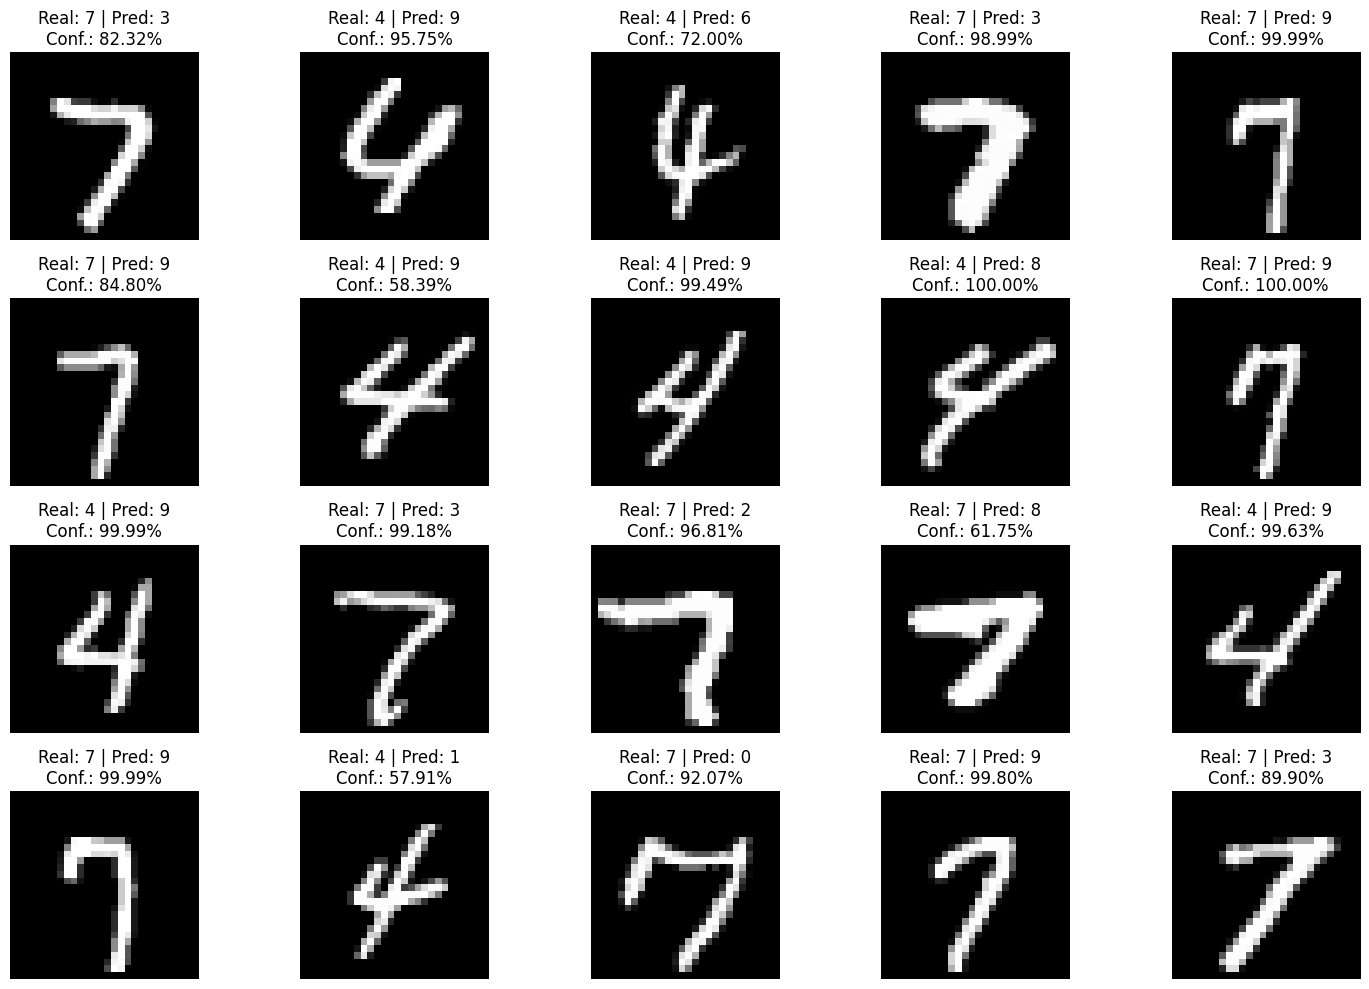

In [35]:
# ============================================================
# CÉLULA 42 — VISUALIZAÇÃO DAS CLASSES OOD
# ============================================================

print("=" * 70)
print("EXEMPLOS DO TESTE OOD")
print("=" * 70)

quantidade_exemplos = min(
    20,
    len(X_ood)
)

# Utilizar o melhor modelo encontrado anteriormente
modelo_ood_visualizacao = modelos_ood[
    melhor_modelo_nome
]

predicoes_visualizacao = predicoes_ood[
    melhor_modelo_nome
]

confiancas_visualizacao = confiancas_ood[
    melhor_modelo_nome
]

plt.figure(figsize=(15, 10))

for i in range(quantidade_exemplos):

    imagem = X_ood[i].reshape(
        28,
        28
    )

    plt.subplot(
        4,
        5,
        i + 1
    )

    plt.imshow(
        imagem,
        cmap="gray"
    )

    plt.title(
        f"Real: {y_ood[i]} | "
        f"Pred: {predicoes_visualizacao[i]}\n"
        f"Conf.: {confiancas_visualizacao[i]:.2%}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [36]:
# ============================================================
# CÉLULA 43 — UPLOAD DAS IMAGENS PRÓPRIAS
# ============================================================

from google.colab import files
from pathlib import Path
import os

print("=" * 70)
print("UPLOAD DAS IMAGENS PRÓPRIAS")
print("=" * 70)

print(
    "\nSelecione uma ou mais imagens dos dígitos "
    "no seu computador."
)

arquivos_upload = files.upload()

print("\nImagens recebidas:")

for nome in arquivos_upload.keys():
    print("-", nome)

print(
    f"\nTotal de imagens: "
    f"{len(arquivos_upload)}"
)

UPLOAD DAS IMAGENS PRÓPRIAS

Selecione uma ou mais imagens dos dígitos no seu computador.


Saving digito_0.png to digito_0 (4).png
Saving digito_9.png to digito_9 (4).png
Saving digito_8.png to digito_8 (4).png
Saving digito_7.png to digito_7 (4).png
Saving digito_6.png to digito_6 (4).png
Saving digito_5.png to digito_5 (4).png
Saving digito_4.png to digito_4 (4).png
Saving digito_3.png to digito_3 (4).png
Saving digito_2.png to digito_2 (4).png
Saving digito_1.png to digito_1 (4).png

Imagens recebidas:
- digito_0 (4).png
- digito_9 (4).png
- digito_8 (4).png
- digito_7 (4).png
- digito_6 (4).png
- digito_5 (4).png
- digito_4 (4).png
- digito_3 (4).png
- digito_2 (4).png
- digito_1 (4).png

Total de imagens: 10


In [37]:
# ============================================================
# CÉLULA 44 — PRÉ-PROCESSAMENTO DAS IMAGENS
# ============================================================

from PIL import Image
import numpy as np

def preprocessar_imagem(caminho):

    # --------------------------------------------------------
    # 1. Abrir imagem e converter para escala de cinza
    # --------------------------------------------------------

    imagem = Image.open(caminho).convert("L")

    array = np.array(
        imagem,
        dtype=np.float32
    )

    # --------------------------------------------------------
    # 2. Normalizar inicialmente para 0-255
    # --------------------------------------------------------

    if array.max() > 0:

        array = (
            array / array.max()
        ) * 255.0

    # --------------------------------------------------------
    # 3. Detectar se é necessário inverter
    # --------------------------------------------------------

    if array.mean() > 127:

        array = 255.0 - array

    # --------------------------------------------------------
    # 4. Remover pequenos ruídos
    # --------------------------------------------------------

    limiar = 30

    mascara = array > limiar

    if not np.any(mascara):

        raise ValueError(
            "Nenhum dígito foi identificado."
        )

    # --------------------------------------------------------
    # 5. Encontrar o bounding box do dígito
    # --------------------------------------------------------

    linhas, colunas = np.where(
        mascara
    )

    y_min = linhas.min()
    y_max = linhas.max()

    x_min = colunas.min()
    x_max = colunas.max()

    recorte = array[
        y_min:y_max + 1,
        x_min:x_max + 1
    ]

    recorte_pil = Image.fromarray(
        recorte.astype(np.uint8)
    )

    # --------------------------------------------------------
    # 6. Redimensionar mantendo proporção
    # --------------------------------------------------------

    largura, altura = recorte_pil.size

    maior_dimensao = max(
        largura,
        altura
    )

    escala = 20 / maior_dimensao

    nova_largura = max(
        1,
        int(round(largura * escala))
    )

    nova_altura = max(
        1,
        int(round(altura * escala))
    )

    recorte_pil = recorte_pil.resize(
        (
            nova_largura,
            nova_altura
        ),
        Image.Resampling.LANCZOS
    )

    # --------------------------------------------------------
    # 7. Criar canvas 28x28
    # --------------------------------------------------------

    canvas = Image.new(
        "L",
        (28, 28),
        0
    )

    # --------------------------------------------------------
    # 8. Centralizar o dígito
    # --------------------------------------------------------

    pos_x = (
        28 - nova_largura
    ) // 2

    pos_y = (
        28 - nova_altura
    ) // 2

    canvas.paste(
        recorte_pil,
        (
            pos_x,
            pos_y
        )
    )

    # --------------------------------------------------------
    # 9. Converter novamente para NumPy
    # --------------------------------------------------------

    resultado = np.array(
        canvas,
        dtype=np.float32
    )

    # --------------------------------------------------------
    # 10. Normalizar para 0-1
    # --------------------------------------------------------

    resultado = (
        resultado / 255.0
    )

    # --------------------------------------------------------
    # 11. Garantir máximo 1.0
    # --------------------------------------------------------

    if resultado.max() > 0:

        resultado = (
            resultado /
            resultado.max()
        )

    # --------------------------------------------------------
    # 12. Transformar 28x28 em 784 características
    # --------------------------------------------------------

    vetor = resultado.reshape(
        1,
        784
    )

    return vetor, resultado

IMAGENS PROCESSADAS
Quantidade: 10


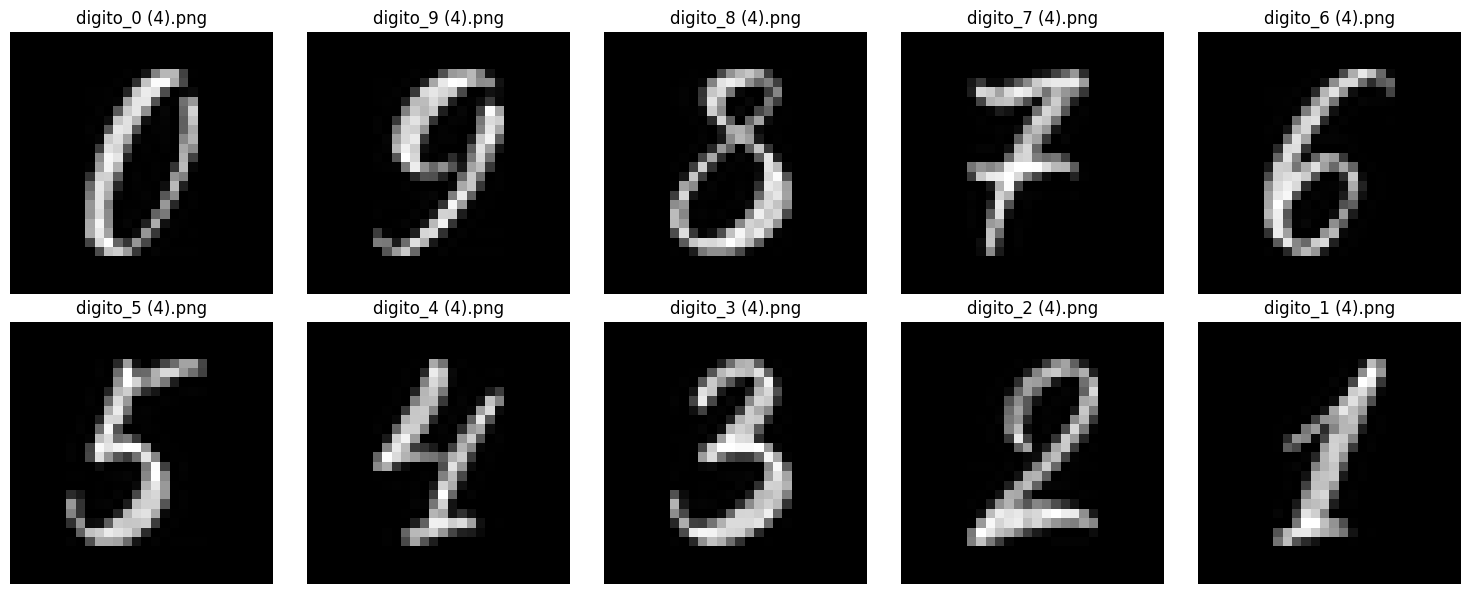

In [38]:
# ============================================================
# CÉLULA 45 — PROCESSAMENTO DAS IMAGENS PRÓPRIAS
# ============================================================

imagens_processadas = []
nomes_processados = []

for nome in arquivos_upload.keys():

    try:

        vetor, imagem_processada = (
            preprocessar_imagem(nome)
        )

        imagens_processadas.append(
            imagem_processada
        )

        nomes_processados.append(
            nome
        )

    except Exception as erro:

        print(
            f"\nErro ao processar {nome}:"
        )

        print(erro)


print("=" * 70)
print("IMAGENS PROCESSADAS")
print("=" * 70)

print(
    "Quantidade:",
    len(imagens_processadas)
)


if len(imagens_processadas) > 0:

    quantidade = len(
        imagens_processadas
    )

    colunas = min(
        5,
        quantidade
    )

    linhas = int(
        np.ceil(
            quantidade / colunas
        )
    )

    plt.figure(
        figsize=(
            15,
            3 * linhas
        )
    )

    for i, imagem in enumerate(
        imagens_processadas
    ):

        plt.subplot(
            linhas,
            colunas,
            i + 1
        )

        plt.imshow(
            imagem,
            cmap="gray"
        )

        plt.title(
            nomes_processados[i]
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [39]:
# ============================================================
# CÉLULA 46 — CLASSIFICAÇÃO DAS IMAGENS PRÓPRIAS
# ============================================================

resultados_imagens = []

for nome in nomes_processados:

    vetor, imagem_processada = (
        preprocessar_imagem(nome)
    )

    predicao = modelo_melhor.predict(
        vetor
    )[0]

    probabilidades = (
        modelo_melhor.predict_proba(
            vetor
        )[0]
    )

    confianca = np.max(
        probabilidades
    )

    resultados_imagens.append({

        "Imagem": nome,

        "Predição": int(
            predicao
        ),

        "Confiança": float(
            confianca
        )
    })


df_imagens = pd.DataFrame(
    resultados_imagens
)

display(
    df_imagens
)

,Imagem,Predição,Confiança
0,digito_0 (4).png,0,0.999817
1,digito_9 (4).png,4,0.513764
2,digito_8 (4).png,8,0.455997
3,digito_7 (4).png,8,0.993178
4,digito_6 (4).png,8,0.742125
5,digito_5 (4).png,5,1.000000
6,digito_4 (4).png,4,0.999999
7,digito_3 (4).png,3,1.000000
8,digito_2 (4).png,2,0.999978
9,digito_1 (4).png,1,0.995912


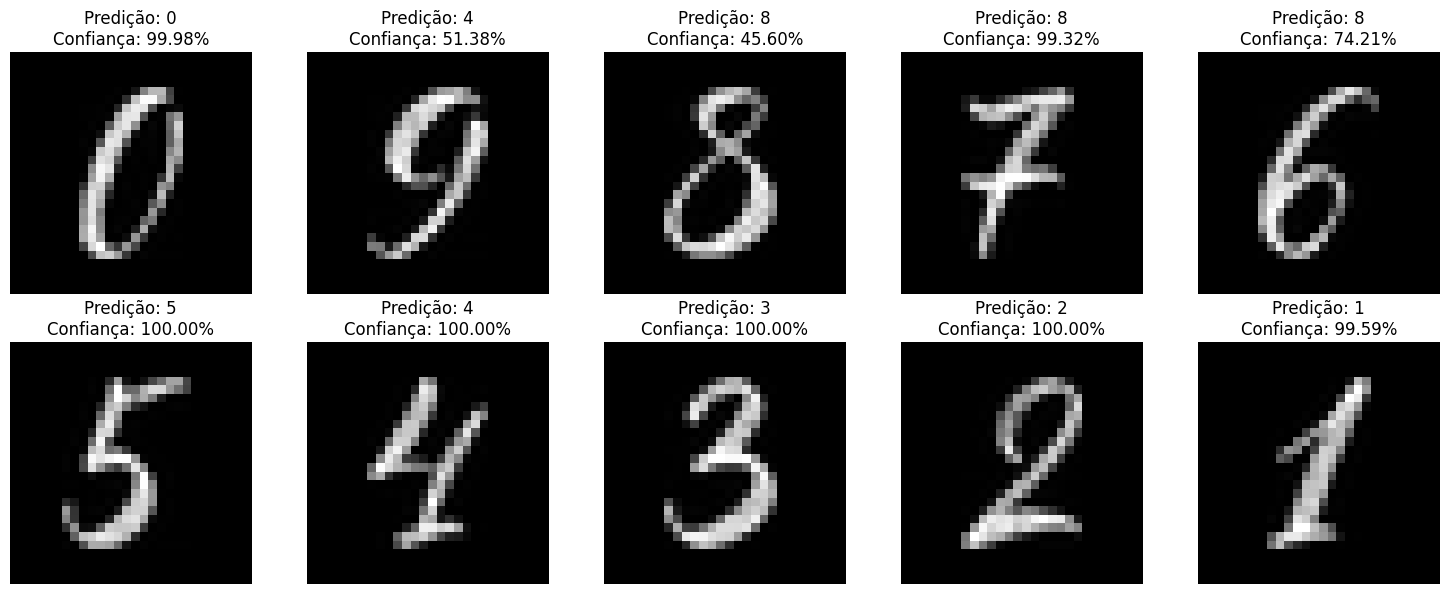

In [40]:
# ============================================================
# CÉLULA 47 — RESULTADO VISUAL DAS IMAGENS PRÓPRIAS
# ============================================================

if len(nomes_processados) > 0:

    quantidade = len(
        nomes_processados
    )

    colunas = min(
        5,
        quantidade
    )

    linhas = int(
        np.ceil(
            quantidade / colunas
        )
    )

    plt.figure(
        figsize=(
            15,
            3 * linhas
        )
    )

    for i, nome in enumerate(
        nomes_processados
    ):

        vetor, imagem = (
            preprocessar_imagem(nome)
        )

        predicao = (
            modelo_melhor.predict(
                vetor
            )[0]
        )

        probabilidades = (
            modelo_melhor.predict_proba(
                vetor
            )[0]
        )

        confianca = np.max(
            probabilidades
        )

        plt.subplot(
            linhas,
            colunas,
            i + 1
        )

        plt.imshow(
            imagem,
            cmap="gray"
        )

        plt.title(
            f"Predição: {predicao}\n"
            f"Confiança: {confianca:.2%}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

else:

    print(
        "Nenhuma imagem foi processada."
    )

In [41]:
# ============================================================
# CÉLULA 48 — RESUMO DAS IMAGENS PRÓPRIAS
# ============================================================

print("=" * 70)
print("RESUMO DAS IMAGENS PRÓPRIAS")
print("=" * 70)

if len(df_imagens) > 0:

    display(
        df_imagens.sort_values(
            by="Confiança",
            ascending=False
        )
    )

    print("\nDistribuição das predições:")

    display(
        df_imagens[
            "Predição"
        ]
        .value_counts()
        .sort_index()
    )

else:

    print(
        "Nenhuma imagem foi processada."
    )

RESUMO DAS IMAGENS PRÓPRIAS


,Imagem,Predição,Confiança
7,digito_3 (4).png,3,1.000000
5,digito_5 (4).png,5,1.000000
6,digito_4 (4).png,4,0.999999
8,digito_2 (4).png,2,0.999978
0,digito_0 (4).png,0,0.999817
9,digito_1 (4).png,1,0.995912
3,digito_7 (4).png,8,0.993178
4,digito_6 (4).png,8,0.742125
1,digito_9 (4).png,4,0.513764
2,digito_8 (4).png,8,0.455997



Distribuição das predições:


,count
Predição,
0,1
1,1
2,1
3,1
4,2
5,1
8,3


In [42]:
# ============================================================
# CÉLULA 49 — COMPARAÇÃO FINAL DOS MODELOS
# ============================================================

print("=" * 70)
print("COMPARAÇÃO FINAL DOS MODELOS")
print("=" * 70)

print("\nColunas disponíveis:")

print(
    df_resultados.columns.tolist()
)

print("\nResultados:")

display(
    df_resultados
)

COMPARAÇÃO FINAL DOS MODELOS

Colunas disponíveis:
['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Tempo Inferência (s)']

Resultados:


,Modelo,Accuracy,Precision,Recall,F1-Score,Tempo Inferência (s)
0,MLP,0.978500,0.978548,0.978500,0.978498,0.108635
1,KNN,0.973214,0.973408,0.973214,0.973185,45.191707
2,Random Forest,0.968000,0.967992,0.968000,0.967979,0.723547


In [43]:
# ============================================================
# CÉLULA 50 — IDENTIFICAÇÃO DO MELHOR MODELO
# ============================================================

melhor_modelo_nome = (
    df_resultados.iloc[0]["Modelo"]
)

melhor_f1 = (
    df_resultados.iloc[0]["F1-Score"]
)

melhor_accuracy = (
    df_resultados.iloc[0]["Accuracy"]
)

melhor_modelo = modelos[
    melhor_modelo_nome
]

print("=" * 70)
print("MELHOR MODELO")
print("=" * 70)

print(
    "Modelo:",
    melhor_modelo_nome
)

print(
    f"Accuracy: "
    f"{melhor_accuracy:.4f}"
)

print(
    f"F1-Score: "
    f"{melhor_f1:.4f}"
)

print(
    "\nO modelo foi selecionado "
    "automaticamente pelo maior F1-Score."
)

MELHOR MODELO
Modelo: MLP
Accuracy: 0.9785
F1-Score: 0.9785

O modelo foi selecionado automaticamente pelo maior F1-Score.


ANÁLISE DOS ERROS
Quantidade total de erros: 301


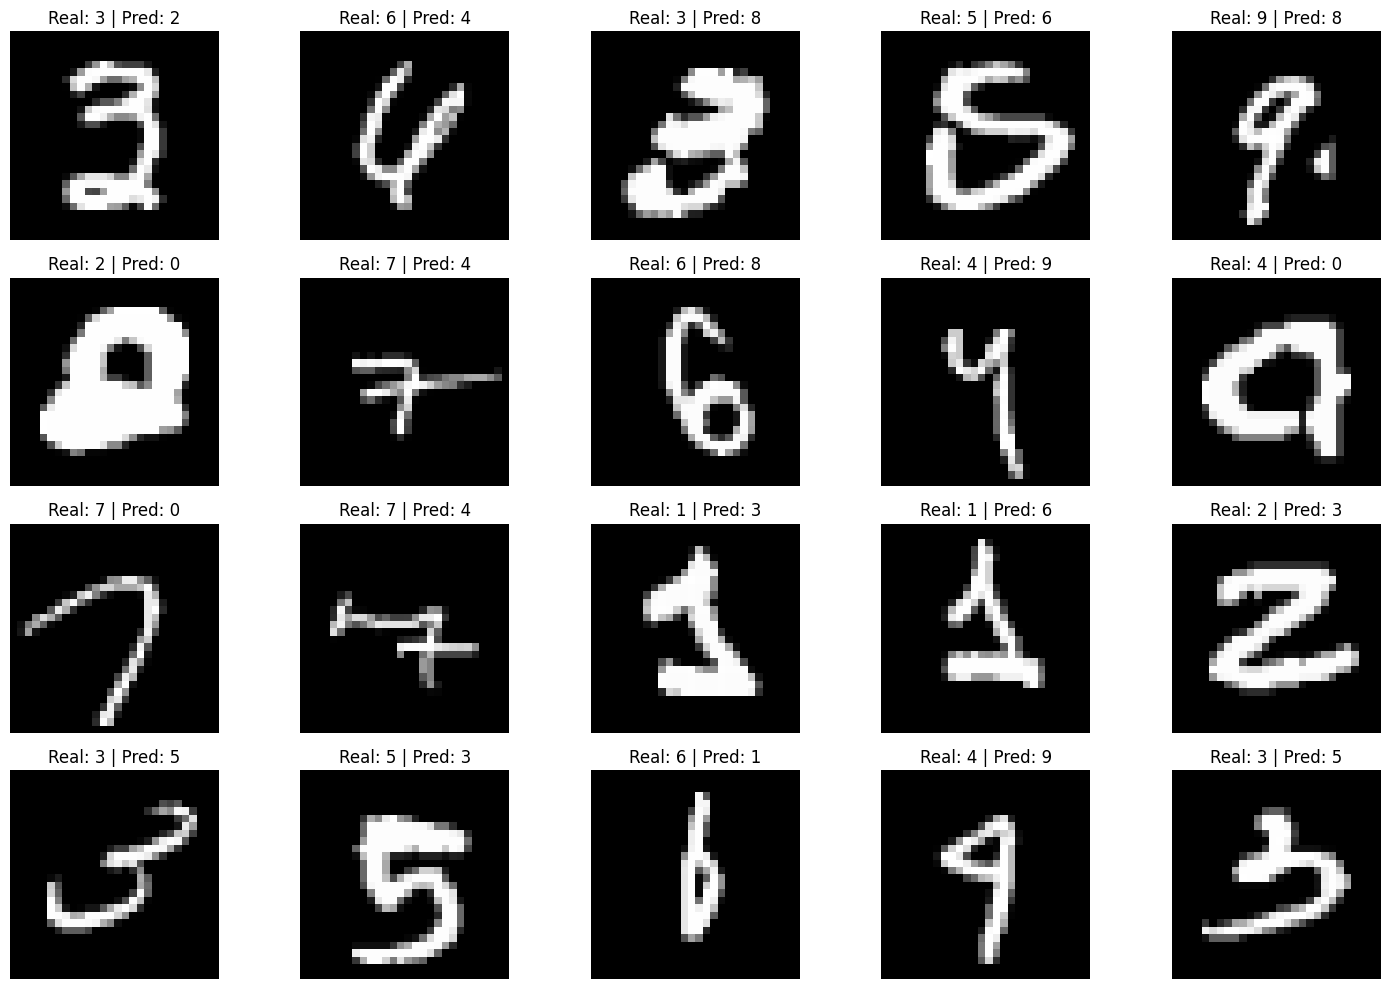

In [44]:
# ============================================================
# CÉLULA 51 — VISUALIZAÇÃO DOS ERROS
# ============================================================

print("=" * 70)
print("ANÁLISE DOS ERROS")
print("=" * 70)

y_pred = predicoes[
    melhor_modelo_nome
]

indices_erros = np.where(
    y_test != y_pred
)[0]

print(
    "Quantidade total de erros:",
    len(indices_erros)
)


if len(indices_erros) > 0:

    quantidade_exemplos = min(
        20,
        len(indices_erros)
    )

    indices_selecionados = (
        indices_erros[
            :quantidade_exemplos
        ]
    )

    plt.figure(
        figsize=(15, 10)
    )

    for i, indice in enumerate(
        indices_selecionados
    ):

        imagem = X_test[
            indice
        ].reshape(
            28,
            28
        )

        plt.subplot(
            4,
            5,
            i + 1
        )

        plt.imshow(
            imagem,
            cmap="gray"
        )

        plt.title(
            f"Real: {y_test[indice]} | "
            f"Pred: {y_pred[indice]}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

else:

    print(
        "Nenhum erro encontrado."
    )

In [45]:
# ============================================================
# CÉLULA 52 — PRINCIPAIS CONFUSÕES
# ============================================================

print("=" * 70)
print("PRINCIPAIS CONFUSÕES DO MODELO")
print("=" * 70)

cm_sem_diagonal = cm.copy()

np.fill_diagonal(
    cm_sem_diagonal,
    0
)

confusoes = []

for classe_real in range(10):

    for classe_predita in range(10):

        quantidade = (
            cm_sem_diagonal[
                classe_real,
                classe_predita
            ]
        )

        if quantidade > 0:

            confusoes.append({

                "Classe Real":
                    classe_real,

                "Classe Predita":
                    classe_predita,

                "Quantidade":
                    quantidade
            })


df_confusoes = pd.DataFrame(
    confusoes
)

df_confusoes = (
    df_confusoes
    .sort_values(
        by="Quantidade",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    df_confusoes.head(10)
)

PRINCIPAIS CONFUSÕES DO MODELO


,Classe Real,Classe Predita,Quantidade
0,4,9,24
1,5,3,11
2,7,2,11
3,7,9,10
4,5,6,10
5,3,5,10
6,8,3,10
7,9,7,9
8,6,0,9
9,3,7,9


In [46]:
# ============================================================
# CÉLULA 53 — RESUMO FINAL DO EXPERIMENTO OOD
# ============================================================

print("=" * 70)
print("RESUMO FINAL — EXPERIMENTO OOD")
print("=" * 70)

print(
    "\nClasses ocultadas:",
    CLASSES_OCULTADAS
)

print(
    "Classes utilizadas no treinamento:",
    CLASSES_CONHECIDAS
)

print(
    "Quantidade de imagens OOD:",
    len(y_ood)
)


for nome in modelos_ood.keys():

    predicao = predicoes_ood[
        nome
    ]

    confianca = confiancas_ood[
        nome
    ]

    print("\n" + "=" * 60)
    print(f"MODELO: {nome}")
    print("=" * 60)

    print(
        f"Confiança média: "
        f"{np.mean(confianca):.4f}"
    )

    for classe in CLASSES_OCULTADAS:

        mascara = (
            y_ood == classe
        )

        predicoes_classe = (
            predicao[mascara]
        )

        if len(predicoes_classe) == 0:
            continue

        valores, quantidades = (
            np.unique(
                predicoes_classe,
                return_counts=True
            )
        )

        print(
            f"\nClasse real {classe}:"
        )

        for valor, quantidade in zip(
            valores,
            quantidades
        ):

            percentual = (
                quantidade /
                len(predicoes_classe)
            ) * 100

            print(
                f"  Predito como {valor}: "
                f"{quantidade} "
                f"({percentual:.2f}%)"
            )

RESUMO FINAL — EXPERIMENTO OOD

Classes ocultadas: [4, 7]
Classes utilizadas no treinamento: [0, 1, 2, 3, 5, 6, 8, 9]
Quantidade de imagens OOD: 2824

MODELO: KNN
Confiança média: 0.9145

Classe real 4:
  Predito como 0: 4 (0.29%)
  Predito como 1: 51 (3.74%)
  Predito como 2: 17 (1.25%)
  Predito como 5: 6 (0.44%)
  Predito como 6: 26 (1.90%)
  Predito como 8: 11 (0.81%)
  Predito como 9: 1250 (91.58%)

Classe real 7:
  Predito como 0: 9 (0.62%)
  Predito como 1: 77 (5.28%)
  Predito como 2: 80 (5.48%)
  Predito como 3: 56 (3.84%)
  Predito como 5: 7 (0.48%)
  Predito como 8: 20 (1.37%)
  Predito como 9: 1210 (82.93%)

MODELO: Random Forest
Confiança média: 0.5685

Classe real 4:
  Predito como 0: 7 (0.51%)
  Predito como 1: 6 (0.44%)
  Predito como 2: 23 (1.68%)
  Predito como 3: 2 (0.15%)
  Predito como 5: 3 (0.22%)
  Predito como 6: 30 (2.20%)
  Predito como 8: 29 (2.12%)
  Predito como 9: 1265 (92.67%)

Classe real 7:
  Predito como 0: 33 (2.26%)
  Predito como 1: 30 (2.06%)
  Pre

In [47]:
# ============================================================
# CÉLULA 54 — ANÁLISE DAS IMAGENS PRÓPRIAS
# ============================================================

print("=" * 70)
print("ANÁLISE DAS IMAGENS PRÓPRIAS")
print("=" * 70)

if len(df_imagens) > 0:

    print(
        "Confiança média:",
        f"{df_imagens['Confiança'].mean():.4f}"
    )

    print(
        "Maior confiança:",
        f"{df_imagens['Confiança'].max():.4f}"
    )

    print(
        "Menor confiança:",
        f"{df_imagens['Confiança'].min():.4f}"
    )

    print(
        "\nResultados:"
    )

    display(
        df_imagens.sort_values(
            by="Confiança",
            ascending=False
        )
    )

else:

    print(
        "Nenhuma imagem própria foi processada."
    )

ANÁLISE DAS IMAGENS PRÓPRIAS
Confiança média: 0.8701
Maior confiança: 1.0000
Menor confiança: 0.4560

Resultados:


,Imagem,Predição,Confiança
7,digito_3 (4).png,3,1.000000
5,digito_5 (4).png,5,1.000000
6,digito_4 (4).png,4,0.999999
8,digito_2 (4).png,2,0.999978
0,digito_0 (4).png,0,0.999817
9,digito_1 (4).png,1,0.995912
3,digito_7 (4).png,8,0.993178
4,digito_6 (4).png,8,0.742125
1,digito_9 (4).png,4,0.513764
2,digito_8 (4).png,8,0.455997


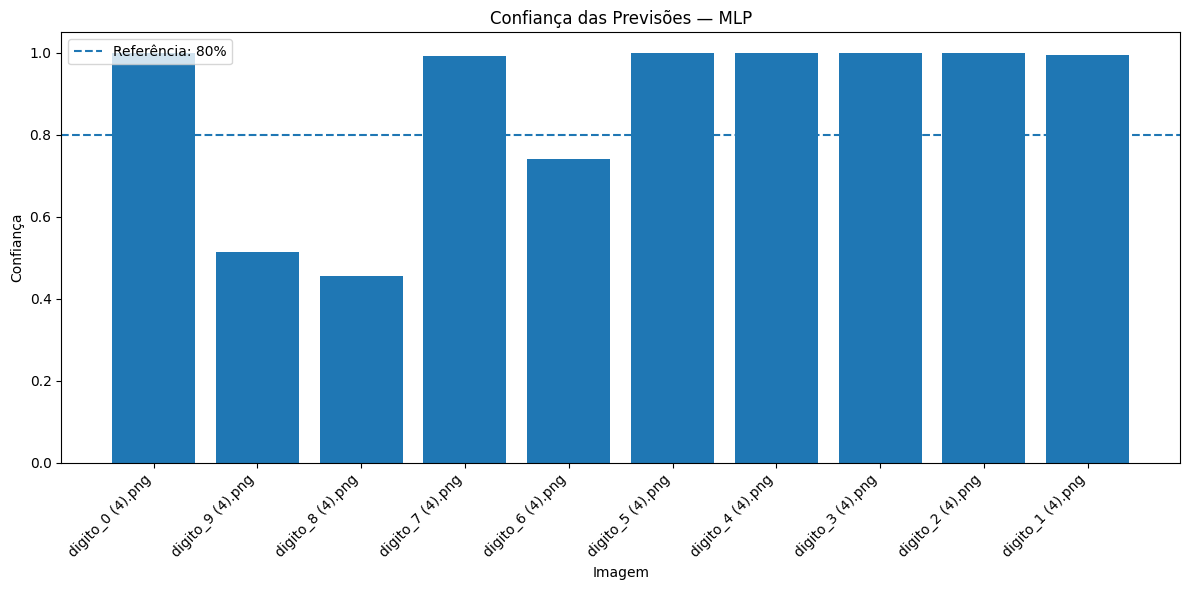

In [48]:
# ============================================================
# CÉLULA 55 — GRÁFICO DE CONFIANÇA
# ============================================================

if len(df_imagens) > 0:

    plt.figure(
        figsize=(12, 6)
    )

    plt.bar(
        df_imagens["Imagem"],
        df_imagens["Confiança"]
    )

    plt.axhline(
        0.80,
        linestyle="--",
        label="Referência: 80%"
    )

    plt.xlabel(
        "Imagem"
    )

    plt.ylabel(
        "Confiança"
    )

    plt.title(
        "Confiança das Previsões "
        f"— {melhor_modelo_nome}"
    )

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.ylim(
        0,
        1.05
    )

    plt.legend()

    plt.tight_layout()

    plt.show()

else:

    print(
        "Nenhuma imagem disponível."
    )

In [49]:
# ============================================================
# CÉLULA 56 — RESUMO EXECUTIVO
# ============================================================

print("=" * 75)
print("RESUMO EXECUTIVO — CLASSIFICAÇÃO MNIST")
print("=" * 75)

print(
    f"""
BASE DE DADOS
-------------
MNIST
Imagens: 28 x 28 pixels
Características por imagem: 784
Classes: 10 dígitos


DIVISÃO DOS DADOS
-----------------
Treinamento: 70%
Validação: 10%
Teste: 20%


MODELOS AVALIADOS
-----------------
KNN
Random Forest
MLP


MELHOR MODELO
-------------
{melhor_modelo_nome}


RESULTADOS NO TESTE
-------------------
Accuracy: {df_resultados.iloc[0]["Accuracy"]:.4f}
Precision: {df_resultados.iloc[0]["Precision"]:.4f}
Recall: {df_resultados.iloc[0]["Recall"]:.4f}
F1-Score: {df_resultados.iloc[0]["F1-Score"]:.4f}


EXPERIMENTO OOD
---------------
Classes ocultadas: {CLASSES_OCULTADAS}
Classes conhecidas: {CLASSES_CONHECIDAS}
Imagens OOD avaliadas: {len(y_ood)}


IMAGENS PRÓPRIAS
----------------
Imagens processadas: {len(df_imagens)}
"""
)

RESUMO EXECUTIVO — CLASSIFICAÇÃO MNIST

BASE DE DADOS
-------------
MNIST
Imagens: 28 x 28 pixels
Características por imagem: 784
Classes: 10 dígitos


DIVISÃO DOS DADOS
-----------------
Treinamento: 70%
Validação: 10%
Teste: 20%


MODELOS AVALIADOS
-----------------
KNN
Random Forest
MLP


MELHOR MODELO
-------------
MLP


RESULTADOS NO TESTE
-------------------
Accuracy: 0.9785
Precision: 0.9785
Recall: 0.9785
F1-Score: 0.9785


EXPERIMENTO OOD
---------------
Classes ocultadas: [4, 7]
Classes conhecidas: [0, 1, 2, 3, 5, 6, 8, 9]
Imagens OOD avaliadas: 2824


IMAGENS PRÓPRIAS
----------------
Imagens processadas: 10



In [50]:
# ============================================================
# CÉLULA 57 — CONCLUSÃO DO PROJETO
# ============================================================

print("=" * 75)
print("CONCLUSÃO DO PROJETO")
print("=" * 75)

print(
    f"""
O experimento demonstrou a aplicação de técnicas de
aprendizado de máquina para classificação de imagens
utilizando a base MNIST.

Foram avaliados três algoritmos: KNN, Random Forest e MLP.
Os modelos foram treinados utilizando conjuntos separados
de treinamento, validação e teste.

O modelo com melhor desempenho foi o {melhor_modelo_nome},
selecionado automaticamente de acordo com o maior F1-Score.

A avaliação foi realizada utilizando métricas como Accuracy,
Precision, Recall e F1-Score, além da análise da matriz de
confusão e dos principais erros de classificação.

Também foi realizado um experimento OOD (Out-of-Distribution),
no qual as classes 4 e 7 foram completamente retiradas do
treinamento.

Dessa forma, o modelo teve contato apenas com as classes
{CLASSES_CONHECIDAS} durante o treinamento e posteriormente
foi testado com imagens das classes 4 e 7, permitindo analisar
como os classificadores se comportam diante de classes que
não estavam presentes durante o aprendizado.

Por fim, foram utilizadas imagens próprias inseridas
diretamente pelo usuário no Google Colab. Essas imagens
passaram por conversão para escala de cinza, normalização,
inversão automática quando necessária, remoção de fundo,
recorte, redimensionamento para 28 x 28 pixels e classificação.

O experimento evidencia que o desempenho de um sistema de
classificação de imagens depende não apenas da escolha do
algoritmo, mas também do pré-processamento, dos hiperparâmetros,
da separação adequada dos dados e da capacidade do modelo de
lidar com dados diferentes daqueles observados durante o
treinamento.
"""
)

CONCLUSÃO DO PROJETO

O experimento demonstrou a aplicação de técnicas de
aprendizado de máquina para classificação de imagens
utilizando a base MNIST.

Foram avaliados três algoritmos: KNN, Random Forest e MLP.
Os modelos foram treinados utilizando conjuntos separados
de treinamento, validação e teste.

O modelo com melhor desempenho foi o MLP,
selecionado automaticamente de acordo com o maior F1-Score.

A avaliação foi realizada utilizando métricas como Accuracy,
Precision, Recall e F1-Score, além da análise da matriz de
confusão e dos principais erros de classificação.

Também foi realizado um experimento OOD (Out-of-Distribution),
no qual as classes 4 e 7 foram completamente retiradas do
treinamento.

Dessa forma, o modelo teve contato apenas com as classes
[0, 1, 2, 3, 5, 6, 8, 9] durante o treinamento e posteriormente
foi testado com imagens das classes 4 e 7, permitindo analisar
como os classificadores se comportam diante de classes que
não estavam presentes durante o aprendizad